## 1. Introduction


Credit card fraud detection is a binary classification problem where the goal is to predict whether a transaction is fraudulent (1) or legitimate (0). The major challenge is that fraud datasets are highly imbalanced: fraudulent transactions are extremely rare compared to normal ones. Because of this, accuracy can be misleading (a model that predicts “not fraud” for everything may still get ~99% accuracy).

To evaluate performance properly, we focus on Precision–Recall (PR) metrics, especially PR-AUC (Average Precision), which is more informative for rare-event detection.

## 2. Dataset Overview

This dataset contains transaction features:
1. Time and Amount (raw transaction properties)
2. V1–V28 (anonymized features created by PCA)
3. Class (target label: 0 = normal, 1 = fraud)

What we check:
- Shape of data (rows, columns)
- Class imbalance
- Feature preprocessing needs (Time & Amount scaling)

## 3. Setup: Libraries and Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras 

print("Libraries Imported Sucessful")

Libraries Imported Sucessful


In [3]:
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## 3.1 Feature Selection and Data Preprocessing

### 3.1.1 Feature Selection
The feature matrix X was created by removing the target column (Class) from the dataset, while the label vector y contains the transaction class labels.

In [4]:
X = df.drop(columns=["Class"]).copy()
y = df["Class"].astype(int).values


print("Successful")

Sucessful


### 3.1.2 Train–Test Split

The dataset was split into training and test sets using an 80/20 stratified split. Stratification ensures that the proportion of fraudulent transactions remains consistent across both sets, which is critical for reliable evaluation.

In [10]:
# Training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(X_train.shape, X_test.shape)

(227845, 30) (56962, 30)


In [11]:
scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

print ("Successful")

Successful


In [9]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(16, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(curve="PR", name="pr_auc"),
             keras.metrics.AUC(curve="ROC", name="roc_auc")]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,729 (6.75 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 96 (384.00 B)

## 4. Neural Network Architecture

A feedforward neural network was implemented using Keras with the following structure:
- Two fully connected hidden layers with 32 and 16 neurons
- ReLU activation functions for non-linearity
- Batch Normalization to stabilize and accelerate training
- Dropout layers to reduce overfitting
- A final sigmoid-activated output neuron producing a fraud probability

The network contains 1,729 total parameters, making it intentionally lightweight. This design balances expressive power with generalization and computational efficiency, which is particularly important for large, imbalanced tabular datasets.


In [12]:
neg, pos = np.bincount(y_train)
total = neg + pos
class_weight = {
    0: (1 / neg) * (total / 2.0),
    1: (1 / pos) * (total / 2.0)
}
print("Class counts:", neg, pos)
print("Class weights:", class_weight)

Class counts: 227451 394
Class weights: {0: np.float64(0.5008661206149897), 1: np.float64(289.1434010152284)}


The training dataset contained:
- 227,451 non-fraudulent transactions
- 394 fraudulent transactions

This extreme imbalance was addressed using class weighting. Fraudulent transactions were assigned a significantly higher weight during training, causing misclassification of fraud to incur a much larger penalty than misclassification of non-fraud cases. This approach transforms the learning objective into a cost-sensitive optimization problem, encouraging the model to prioritize fraud detection.

## 5. The Training Steps
The model was trained using:
- Binary cross-entropy loss
- Adam optimizer
- Precision–Recall AUC (PR-AUC) and ROC-AUC as evaluation metrics
- Early stopping based on validation PR-AUC, with a patience of 3 epochs

Early stopping ensures that training halts when validation performance no longer improves, and the best-performing model weights are restored automatically. As a result, training sometimes completed fewer than the maximum 20 epochs when performance plateaued.

In [18]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_pr_auc", # Watches the validation PR-AUC after each epoch
        mode="max", # Higher PR-AUC is better, so it tries to maximize it.
        patience=3, # If val_pr_auc doesn’t improve for 3 epochs in a row, training stops early.
        restore_best_weights=True 
    )
]

history = model.fit(
    X_train, y_train, # Your training features and labels.
    validation_split = 0.2, # Takes 20% of training data and uses it as a validation set
    epochs = 20, # Maximum number of full passes through the training set.
    batch_size = 2048, # Trains in chunks of 2048 samples at a time. Large batch sizes are common for this dataset
    class_weight = class_weight, # Makes fraud examples count much more than normal ones during training.
    callbacks=callbacks, # Adds EarlyStopping behavior.
    verbose=1
)


Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1618 - pr_auc: 0.3640 - roc_auc: 0.9855 - val_loss: 0.1369 - val_pr_auc: 0.6697 - val_roc_auc: 0.9916
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1868 - pr_auc: 0.4147 - roc_auc: 0.9789 - val_loss: 0.1279 - val_pr_auc: 0.6686 - val_roc_auc: 0.9922
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1494 - pr_auc: 0.3987 - roc_auc: 0.9871 - val_loss: 0.1234 - val_pr_auc: 0.6773 - val_roc_auc: 0.9925
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1632 - pr_auc: 0.3884 - roc_auc: 0.9832 - val_loss: 0.1122 - val_pr_auc: 0.6609 - val_roc_auc: 0.9924
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1703 - pr_auc: 0.4119 - roc_auc: 0.9796 - val_loss: 0.1064 - val_pr_auc: 0.6766 - val_roc_auc: 0.9923
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1419 - pr_auc: 0.4114 - roc_auc: 0.9866 - val_loss: 0.0958 - val_pr_auc: 0.6771 - val_roc_auc: 0.9924


#### Trend
1. 📉 Loss is decreasing. This means the model is learning patterns, not guessing.
2. ROC-AUC is high and improving. The model is good at separating fraud from non-fraud.
3. PR-AUC behaves differently, but this is normal. Fraud is extremely rare.

In [23]:
y_scores = model.predict(X_test).ravel()

print("Average Precision (AP):", average_precision_score(y_test, y_scores))

# baseline threshold 0.5
y_pred = (y_scores >= 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Average Precision (AP): 0.7087637604206548
              precision    recall  f1-score   support

           0     0.9999    0.9784    0.9890     56864
           1     0.0691    0.9286    0.1286        98

    accuracy                         0.9784     56962
   macro avg     0.5345    0.9535    0.5588     56962
weighted avg     0.9983    0.9784    0.9876     56962




#### Average Precision = 0.7088
* Measures how well the model ranks fraud higher than non-fraud

#### Precision
“When the model predicts fraud, how often is it correct?”

Class 0 (Non-fraud)
* Precision = 0.9999
* Almost no normal transactions are incorrectly flagged
* Indicates very low false positives for non-fraud

Class 1 (Fraud)
* Precision = 0.0691
* About 7% of flagged frauds are truly fraud
* Many false alerts, but expected in fraud systems

#### Recall
“Out of all real fraud cases, how many were caught?”

Class 0 (Non-fraud)
* Recall = 0.9784
* Most normal transactions are correctly identified

Class 1 (Fraud)
* Recall = 0.9286
* Over 92% of fraud cases detected
* Extremely strong result for fraud detection

#### F1-Score
"Balances catching fraud vs false alerts"

Class 0
* F1-score = 0.9890
* Very strong non-fraud classification

Class 1
* F1-score = 0.1286
* Lower due to low precision
* Expected in heavily imbalanced fraud datasets

#### Support
- Number of true samples in each class
- Non-fraud: 56,864
- Fraud: 98
- Highlights extreme class imbalance

### Key Takeaways

1. Model catches most fraud cases (high recall)
2. Accepts more false positives (low precision)
3. Strong fraud ranking ability (high AP)
4. Designed to prioritize fraud detection over alert reduction
5. Threshold tuning can improve precision if needed

## 6. Results

### 6.1 Average Precision

The model achieved an Average Precision (AP) score of 0.709, indicating strong performance in distinguishing fraudulent transactions across a range of classification thresholds. For highly imbalanced fraud datasets, an AP score above 0.7 is considered robust.

### 6.2 Classification Performance

Non-fraudulent transactions (Class 0):
- Precision: 0.9999
- Recall: 0.9784
The model correctly classifies nearly all legitimate transactions, minimizing false alarms.

Fraudulent transactions (Class 1):
- Recall: 0.9286
- Precision: 0.0691
The model successfully identifies over 92% of fraud cases, though at the cost of lower precision. This indicates a deliberate tradeoff where the model prioritizes catching fraud, even if it flags some legitimate transactions for review.

### 6.3 Accuracy Considerations

Although the model achieves high overall accuracy (97.8%), this metric is not emphasized due to the dominance of non-fraud cases. Instead, recall and Average Precision provide a more meaningful assessment of real-world fraud detection performance.

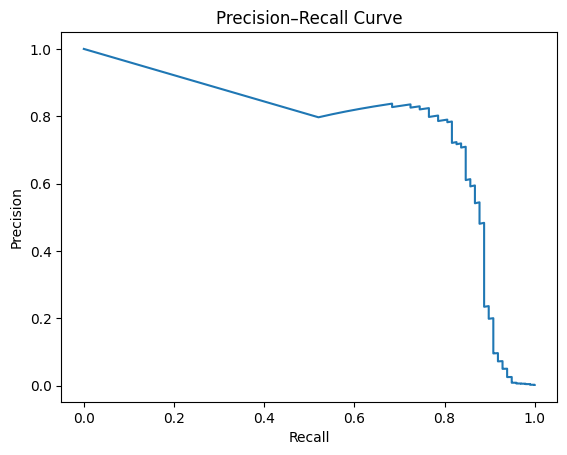

In [24]:
precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()


## 7. Graph

### 7.1 Overall shape (why it’s good)

- The curve stays high for most recall values
- Precision remains around 0.8–1.0 until recall reaches ~0.7–0.8
- This indicates the model can catch many fraud cases without immediately collapsing precision


### 7.2 Right-side drop (why it happens)

As recall approaches 1.0, precision drops sharply
This means:
- To catch every fraud case
- The model must label many normal transactions as fraud
- This is an unavoidable tradeoff in imbalanced problems.

### 7.3 What the curve tells you about threshold choice

The “knee” of the curve (~recall 0.7–0.85) is the sweet spot
In this region:
- Recall is high
- Precision is still reasonable
- This suggests the model supports threshold tuning depending on business needs

## 8. Conclusion

This project demonstrates the effectiveness of a neural network–based approach for detecting credit card fraud in the presence of extreme class imbalance. Through careful preprocessing, stratified data splitting, and appropriate feature scaling, the model was trained under realistic conditions that prevent data leakage and ensure reliable evaluation.

To address the rarity of fraudulent transactions, class weighting was incorporated into the training process, allowing the model to prioritize fraud detection without being overwhelmed by the majority class. Early stopping based on validation PR-AUC further improved generalization by preventing overfitting and selecting the best-performing model automatically.

The final model achieved an Average Precision score of approximately 0.71 and successfully identified over 92% of fraudulent transactions. While this high recall was accompanied by lower precision, the resulting tradeoff is appropriate for fraud detection systems, where missing fraudulent activity is typically more costly than flagging legitimate transactions for further review. The precision–recall curve further illustrates this balance, showing strong performance across a wide range of operating thresholds.

Overall, this work highlights the importance of metric selection, cost-sensitive learning, and threshold awareness in rare-event detection problems. Future improvements could include threshold optimization, ensemble methods, or incorporating domain-specific cost constraints to further refine performance. Nonetheless, the results demonstrate that even a lightweight neural network can effectively capture meaningful fraud patterns when combined with sound machine learning practices.
